# Experience 3 - 2 modeles, 3 predictions combinees

Ce notebook ne reentraine pas `P1`. Il charge le pipeline historique exporte par `notebooks/experience_1.ipynb`, construit `P2` et `P3` a partir du modele simule, puis applique la formule metier :

`P_final = P1 + (P3 - P2)`

## 1. Architecture retenue

La logique retenue est bien **2 modeles, 3 predictions combinees** :

- le modele historique produit `P1`, c'est-a-dire un rendement moyen realiste pour un couple `pays + culture` ;
- le modele simule est utilise une premiere fois sur un profil de reference pour produire `P2` ;
- le meme modele simule est reutilise une seconde fois sur les conditions locales utilisateur pour produire `P3` ;
- l'ajustement local vaut `P3 - P2`, et la prediction finale vaut `P1 + (P3 - P2)`.

Cette separation aligne le notebook avec l'experience utilisateur cible :

- **mode Prediction** : une culture choisie, puis un rendement final ajuste ;
- **mode Recommandation** : toutes les cultures disponibles pour un pays, puis un classement par rendement final.

In [21]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

from scripts.prediction_adjustment import (
    HISTORICAL_METADATA_PATH,
    HISTORICAL_MODEL_PATH,
    SIMULATION_METADATA_PATH,
    SIMULATION_MODEL_PATH,
    build_historical_reference_frame,
    build_simulation_global_reference,
    load_historical_model,
    load_historical_wide_dataset,
    load_or_train_simulation_model,
    predict_adjusted_yield,
    recommend_crops,
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 2. Audit des artefacts d'entree

`experience_3` depend explicitement de l'artefact historique produit par `experience_1`. Le notebook ne doit donc pas recreer ni reentrainer la brique `P1`.

In [22]:
artifact_audit_df = pd.DataFrame(
    [
        {'artifact': 'p1_historical_pipeline', 'path': str(HISTORICAL_MODEL_PATH), 'exists': HISTORICAL_MODEL_PATH.exists()},
        {'artifact': 'p1_historical_metadata', 'path': str(HISTORICAL_METADATA_PATH), 'exists': HISTORICAL_METADATA_PATH.exists()},
        {'artifact': 'p23_simulation_pipeline', 'path': str(SIMULATION_MODEL_PATH), 'exists': SIMULATION_MODEL_PATH.exists()},
        {'artifact': 'p23_simulation_metadata', 'path': str(SIMULATION_METADATA_PATH), 'exists': SIMULATION_METADATA_PATH.exists()},
    ]
)
display(artifact_audit_df)

assert HISTORICAL_MODEL_PATH.exists(), 'Le pipeline historique P1 doit etre produit par experience_1 avant experience_3.'
assert HISTORICAL_METADATA_PATH.exists(), 'Les metadonnees P1 doivent etre produites par experience_1 avant experience_3.'

p1_loaded = load_historical_model()
historical_df = load_historical_wide_dataset()
simulation_loaded, simulation_df = load_or_train_simulation_model(force_retrain=False, save_artifact=True)

target_year = int(p1_loaded.metadata['target_year'])
reference_df = build_historical_reference_frame(historical_df, target_year=target_year)
strategy_df = historical_df.merge(reference_df, on=['area', 'crop'], how='left')
simulation_global_reference = build_simulation_global_reference(simulation_df)

p1_metadata_overview_df = pd.DataFrame(
    [
        {'metric': 'model_name', 'value': p1_loaded.metadata['model_name']},
        {'metric': 'target_year', 'value': p1_loaded.metadata['target_year']},
        {'metric': 'feature_count', 'value': len(p1_loaded.metadata['feature_columns'])},
        {'metric': 'test_rmse', 'value': p1_loaded.metadata['metrics']['test_rmse']},
        {'metric': 'test_mae', 'value': p1_loaded.metadata['metrics']['test_mae']},
        {'metric': 'test_r2', 'value': p1_loaded.metadata['metrics']['test_r2']},
    ]
)
simulation_metadata_overview_df = pd.DataFrame(
    [
        {'metric': 'model_name', 'value': simulation_loaded.metadata['model_name']},
        {'metric': 'feature_count', 'value': len(simulation_loaded.metadata['feature_columns'])},
        {'metric': 'test_rmse', 'value': simulation_loaded.metadata['metrics']['test_rmse']},
        {'metric': 'test_mae', 'value': simulation_loaded.metadata['metrics']['test_mae']},
        {'metric': 'test_r2', 'value': simulation_loaded.metadata['metrics']['test_r2']},
    ]
)

display(p1_metadata_overview_df)
display(simulation_metadata_overview_df)


,artifact,path,exists
0,p1_historical_pipeline,/Users/steph/Code/Python/Jupyter/OCR_Projet12/...,True
1,p1_historical_metadata,/Users/steph/Code/Python/Jupyter/OCR_Projet12/...,True
2,p23_simulation_pipeline,/Users/steph/Code/Python/Jupyter/OCR_Projet12/...,True
3,p23_simulation_metadata,/Users/steph/Code/Python/Jupyter/OCR_Projet12/...,True


,metric,value
0,model_name,random_forest_search_01
1,target_year,2016
2,feature_count,79
3,test_rmse,2.056729
4,test_mae,0.803685
5,test_r2,0.946969


,metric,value
0,model_name,linear_regression
1,feature_count,8
2,test_rmse,0.496689
3,test_mae,0.396065
4,test_r2,0.91395


## 3. Ce qui produit `P1`, `P2` et `P3`

- `P1` vient exclusivement du pipeline historique sauvegarde par `notebooks/experience_1.ipynb`.
- `P2` et `P3` viennent du meme modele simule lineaire.
- `P2` correspond a un profil de reference documente a partir de l'historique local quand il existe, avec repli sur la mediane de culture puis sur la reference globale simulee.
- `P3` reprend ce meme profil mais remplace les conditions locales par les valeurs saisies par l'utilisateur.

,metric,value
0,share_rows_with_rainfall_reference,0.7705
1,share_rows_with_temperature_reference,0.5908
2,share_crops_with_rainfall_fallback,1.0000
3,share_crops_with_temperature_fallback,1.0000


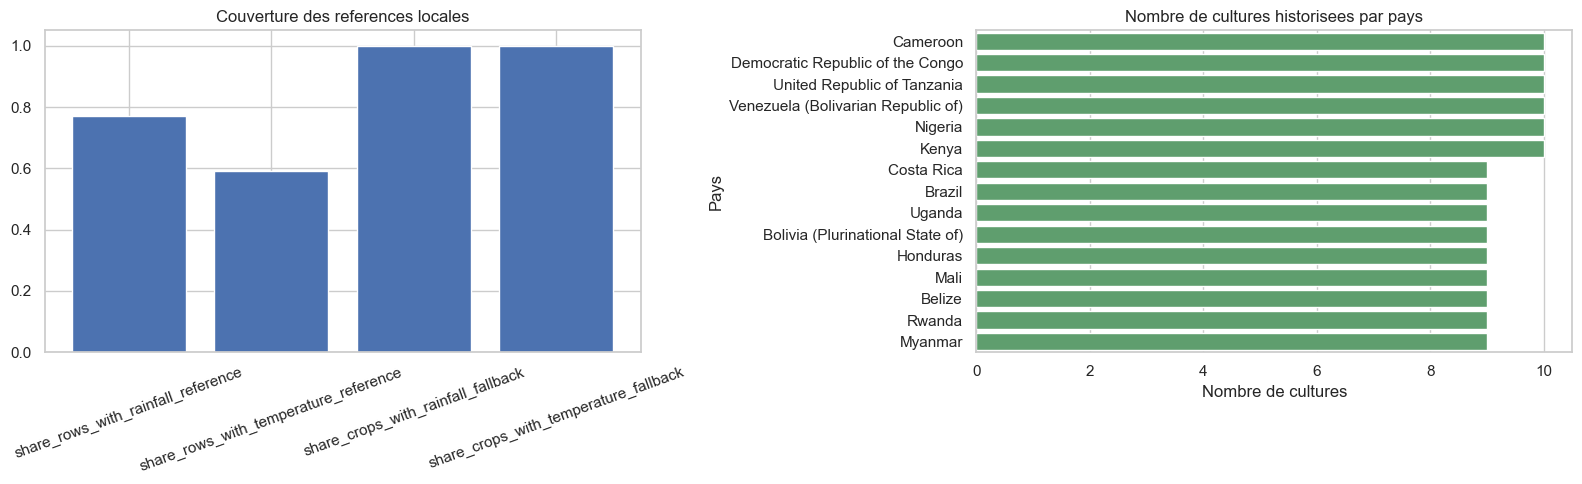

In [23]:
coverage_summary = pd.DataFrame(
    {
        'metric': [
            'share_rows_with_rainfall_reference',
            'share_rows_with_temperature_reference',
            'share_crops_with_rainfall_fallback',
            'share_crops_with_temperature_fallback',
        ],
        'value': [
            float(reference_df['reference_rainfall_mm'].notna().mean()),
            float(reference_df['reference_temperature_celsius'].notna().mean()),
            float(reference_df['crop_reference_rainfall_mm'].notna().mean()),
            float(reference_df['crop_reference_temperature_celsius'].notna().mean()),
        ],
    }
)
display(coverage_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
coverage_plot_df = coverage_summary.copy()
axes[0].bar(coverage_plot_df['metric'], coverage_plot_df['value'], color='#4c72b0')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Couverture des references locales')
axes[0].tick_params(axis='x', rotation=20)

crop_counts_df = (
    historical_df.groupby('area')['crop']
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .rename('crop_count')
    .reset_index()
)
sns.barplot(data=crop_counts_df, x='crop_count', y='area', ax=axes[1], color='#55a868')
axes[1].set_title('Nombre de cultures historisees par pays')
axes[1].set_xlabel('Nombre de cultures')
axes[1].set_ylabel('Pays')

plt.tight_layout()
plt.show()


## 4. Mode Prediction

Le mode Prediction correspond a un utilisateur qui choisit un pays, une culture, puis des conditions locales de parcelle. Le notebook calcule alors `P1`, `P2`, `P3` et la prediction finale ajustee.

,country,crop,p1_historical_prediction,p2_reference_simulation,p3_user_simulation,local_adjustment,final_prediction,reference_profile,user_profile,rainfall_reference_source,temperature_reference_source
0,France,Maize,8.5129,6.0536,5.6231,-0.4305,8.0824,"{'region': 'North', 'soil_type': 'Sandy', 'rai...","{'region': 'North', 'soil_type': 'Sandy', 'rai...",row_latest_history,row_latest_history


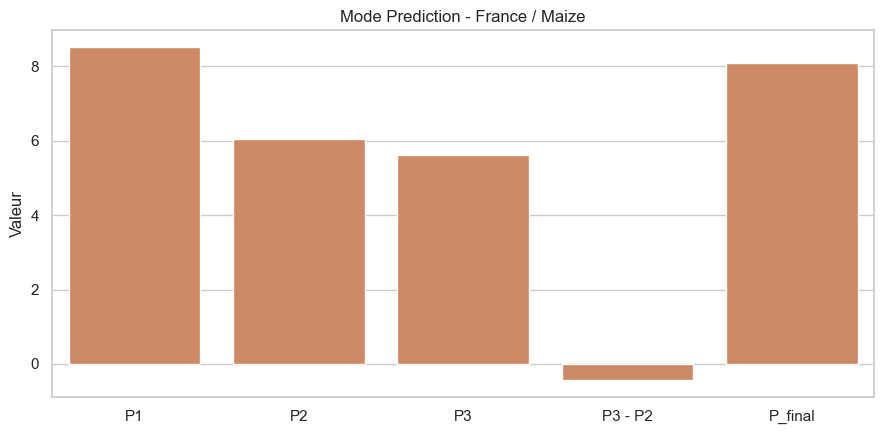

In [24]:
example_area = 'France' if 'France' in strategy_df['area'].values else strategy_df['area'].iloc[0]
example_crop = strategy_df.loc[strategy_df['area'] == example_area, 'crop'].sort_values().iloc[0]

example_user_conditions = dict(simulation_global_reference)
example_user_conditions.update(
    {
        'rainfall_mm': float(simulation_global_reference['rainfall_mm'] * 0.85),
        'temperature_celsius': float(simulation_global_reference['temperature_celsius'] + 2.0),
        'fertilizer_used': True,
        'irrigation_used': True,
    }
)

prediction_example = predict_adjusted_yield(
    area=example_area,
    crop=example_crop,
    user_conditions=example_user_conditions,
)

prediction_components_df = pd.DataFrame(
    [
        {'component': 'P1', 'value': prediction_example['p1_historical_prediction']},
        {'component': 'P2', 'value': prediction_example['p2_reference_simulation']},
        {'component': 'P3', 'value': prediction_example['p3_user_simulation']},
        {'component': 'P3 - P2', 'value': prediction_example['local_adjustment']},
        {'component': 'P_final', 'value': prediction_example['final_prediction']},
    ]
)
display(pd.DataFrame([prediction_example]).round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=prediction_components_df, x='component', y='value', ax=ax, color='#dd8452')
ax.set_title(f'Mode Prediction - {example_area} / {example_crop}')
ax.set_xlabel('')
ax.set_ylabel('Valeur')
plt.tight_layout()
plt.show()


## 5. Mode Recommandation

Le mode Recommandation fixe un pays et un meme contexte local utilisateur, puis applique la formule a toutes les cultures disponibles dans l'historique de ce pays. Le classement final est trie par rendement final decroissant.

,country,crop,p1_historical_prediction,p2_reference_simulation,p3_user_simulation,local_adjustment,final_prediction,recommendation_rank,rainfall_reference_source,temperature_reference_source
0,France,Potatoes,41.4755,6.0536,5.6231,-0.4305,41.0450,1,row_latest_history,row_latest_history
1,France,Maize,8.5129,6.0536,5.6231,-0.4305,8.0824,2,row_latest_history,row_latest_history
2,France,Wheat,6.7981,6.0536,5.6231,-0.4305,6.3676,3,row_latest_history,row_latest_history
3,France,Sorghum,5.6984,6.0536,5.6231,-0.4305,5.2679,4,row_latest_history,row_latest_history
4,France,"Rice, paddy",4.8155,6.0536,5.6231,-0.4305,4.3850,5,row_latest_history,row_latest_history
5,France,Soybeans,2.7713,6.0536,5.6231,-0.4305,2.3408,6,row_latest_history,row_latest_history


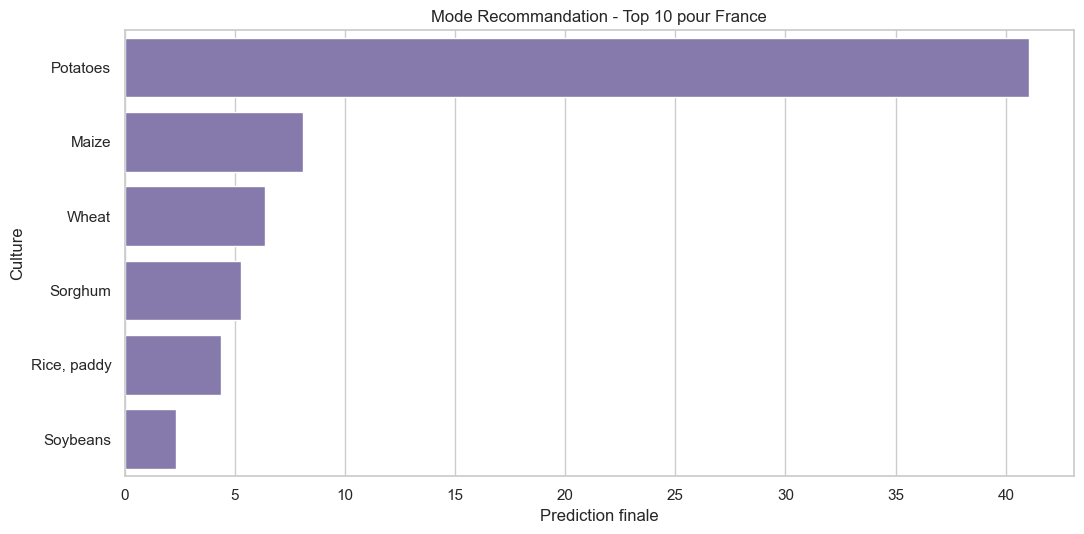

In [25]:
recommendation_df = recommend_crops(
    area=example_area,
    user_conditions=example_user_conditions,
)

display(recommendation_df.round(4))

top_recommendations_df = recommendation_df.head(10).copy()
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=top_recommendations_df, x='final_prediction', y='crop', ax=ax, color='#8172b3')
ax.set_title(f'Mode Recommandation - Top 10 pour {example_area}')
ax.set_xlabel('Prediction finale')
ax.set_ylabel('Culture')
plt.tight_layout()
plt.show()


## 6. Verifications de coherence

On ajoute quelques assertions simples pour verrouiller les hypotheses de la strategie avant integration future dans FastAPI et Streamlit.

In [26]:
experience_3_nb_path = Path('notebooks/experience_3.ipynb')
if not experience_3_nb_path.exists():
    experience_3_nb_path = Path('experience_3.ipynb')
experience_3_nb = json.loads(experience_3_nb_path.read_text(encoding='utf-8'))
other_code_sources = [
    ''.join(cell.get('source', []))
    for idx, cell in enumerate(experience_3_nb['cells'])
    if cell.get('cell_type') == 'code' and idx != 12
]
combined_other_code = '\n'.join(other_code_sources)

assert p1_loaded.metadata['training_notebook'] in {'experience_1.ipynb', 'notebooks/experience_1.ipynb'}
assert 'candidate_models =' not in combined_other_code
assert 'build_model_pipeline(best_model_spec' not in combined_other_code
assert np.isfinite(prediction_example['p1_historical_prediction'])
assert np.isfinite(prediction_example['p2_reference_simulation'])
assert np.isfinite(prediction_example['p3_user_simulation'])
assert np.isfinite(prediction_example['local_adjustment'])
assert np.isfinite(prediction_example['final_prediction'])
assert recommendation_df['final_prediction'].is_monotonic_decreasing
assert (recommendation_df['final_prediction'] >= 0).all()
assert recommendation_df.loc[0, 'recommendation_rank'] == 1

print('Verifications OK : P1 charge depuis experience_1, predictions numeriques, classement trie, plancher a 0 respecte.')


Verifications OK : P1 charge depuis experience_1, predictions numeriques, classement trie, plancher a 0 respecte.


## 7. Lecture finale

La separation des responsabilites est maintenant nette :

- `notebooks/experience_1.ipynb` entraine et sauvegarde le modele historique `P1` ;
- `notebooks/experience_3.ipynb` charge cet artefact sans le reentrainer ;
- le modele simule est utilise deux fois pour produire `P2` puis `P3` ;
- la formule finale appliquee est bien `P1 + (P3 - P2)` ;
- le notebook montre explicitement le mode Prediction et le mode Recommandation.